In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch
sys.path.append('../../')

In [3]:
from neural_control.dynamics import SequentialDualSourcingModel, fractional_decoupling, binary_decoupling
from neural_control.demand_generators import FileBasedDemandGenerator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy

torch.set_default_tensor_type(torch.cuda.FloatTensor)

In [4]:
service_type = 'high_service'

In [5]:
base_cofing = dict(h = 5, b = 495, cr = 0, ce = 20, lr = 2, le = 0)
service_configs = dict(high_service = dict(b=495), low_service = dict(b=95))

In [6]:
current_results = [
    dict(baselines='NNC', b=495, mean_cost=747117, median_cost=692118, method='current'),
    dict(baselines='CDI', b=495, mean_cost=773993, median_cost=770362, method='current'),
    dict(baselines='NNC', b=495, mean_cost=620968, median_cost=666600, method='future'),
    dict(baselines='CDI', b=495, mean_cost=722346, median_cost=716001, method='future'),    
    dict(baselines='NNC', b=95, mean_cost=583873, median_cost=563711, method='current'),
    dict(baselines='CDI', b=95, mean_cost=736018, median_cost=735265, method='current'),
    dict(baselines='NNC', b=95, mean_cost=564003, median_cost=541150, method='future'),
    dict(baselines='CDI', b=95, mean_cost=684495, median_cost=682958, method='future')
]
pd.DataFrame(current_results)

,baselines,b,mean_cost,median_cost,method
0,NNC,495,747117,692118,current
1,CDI,495,773993,770362,current
2,NNC,495,620968,666600,future
3,CDI,495,722346,716001,future
4,NNC,95,583873,563711,current
5,CDI,95,736018,735265,current
6,NNC,95,564003,541150,future
7,CDI,95,684495,682958,future


In [7]:
fbd = FileBasedDemandGenerator()

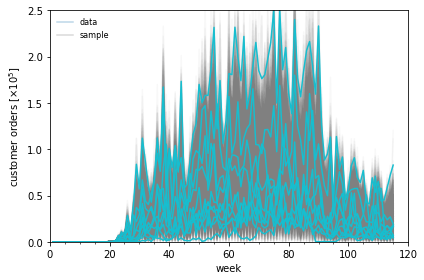

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    #fbd.plot_gaussian_process_vs_model()
    #fbd.plot_distributions()
    fbd.plot_samples_vs_data()


In [9]:
sourcing_parameters = dict(T=fbd.max_weeks)
sourcing_parameters.update(base_cofing)
sourcing_parameters.update(service_configs['high_service'])

In [10]:
N = 1 # aka minibatch size
T = fbd.max_weeks

sds = SequentialDualSourcingModel(**sourcing_parameters)
sds.I_0 = torch.tensor(0.0, requires_grad=True)


In [11]:
class SequentialController(torch.nn.Module):
    def __init__(self, lr, le):
        super().__init__()
        self.sequential_layer = torch.nn.LSTM(input_size=1, hidden_size=38, num_layers=1, batch_first=True)
        self.layer_norm = torch.nn.LayerNorm([T, 1])
        
        self.sequential_layer_2 = torch.nn.LSTM(input_size=1, hidden_size=38, num_layers=1, batch_first=True)
        self.layer_norm_2 = torch.nn.LayerNorm([T, 1])
        
        self.lr = lr
        self.le = le
        
        
    def calculate_qs(self, h, force_positive=True):
        qr_coeff = torch.relu(h[:, :, 0]) if force_positive else h[:, :, 0]
        qr_quant = fractional_decoupling(qr_coeff*torch.exp(h[:, :, 1:18].sum(-1)))
        qr_dec = binary_decoupling(h[:, :, 18])
        
        qe_coeff = torch.relu(h[:, :, 19]) if force_positive else h[:, :, 19]
        qe_quant = fractional_decoupling(qe_coeff*torch.exp(h[:, :, 20:37].sum(-1)))
        qe_dec = binary_decoupling(h[:, :, 37])
        
        return qr_quant*qr_dec, qe_quant*qe_dec
        
    def forward(self, state):
        
        total_qr = torch.zeros_like(state)
        total_qe = torch.zeros_like(state)
        for i in range(max(2*self.lr, 2*self.le)):            
            arrived_qr = total_qr.roll(self.lr, dims=(1,)).unsqueeze(-1)
            arrived_qr[:, :self.lr, :] = 0*arrived_qr[:, :self.lr, :]

            arrived_qe = total_qe.roll(self.le, dims=(1,)).unsqueeze(-1)
            arrived_qe[:, :self.le, :] = 0*arrived_qe[:, :self.le, :]
            
            
            x = state + total_qr.cumsum(1) + total_qe.cumsum(1)#self.layer_norm(state)
            
            ln = self.layer_norm if i == 0 else self.layer_norm_2
            
            
            if i%2 == 0 or i ==0:
                h, (h_T, c_T) =  self.sequential_layer(ln(x))
            else:
                h, (h_T, c_T) =  self.sequential_layer_2(ln(x))
                
            qr, qe = self.calculate_qs(h, force_positive=False)
            total_qr += qr.unsqueeze(-1)
            total_qe += qe.unsqueeze(-1)        
       
        qr, qe = torch.relu(qr), torch.relu(qe)
        return qr,qe

In [12]:
sc = SequentialController(sourcing_parameters['lr'], sourcing_parameters['le'])

In [13]:
best_model = [deepcopy(sc.state_dict())]
best_cost = [np.infty]

In [14]:
optimizer = torch.optim.RMSprop(sc.parameters(), lr=1e-4)
optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)

In [15]:
N=16
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

In [16]:
future_demands.shape

torch.Size([16, 115])

In [17]:
sc.train()
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
demands = torch.cat([initial_demands, future_demands], dim=-1).float()
past_demands = demands[:, :-1]
compressed_input = (inital_inventories - past_demands).unsqueeze(-1)

for i in range(50000):
    optimizer.zero_grad()
    new_qr, new_qe = sc(compressed_input)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe
    
    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]
    
    
    
    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    mean_costs = costs.mean()
    J = mean_costs#((costs > costs.quantile(0.5, dim=1, keepdim=True))*costs).mean()#mean_costs #+ (1.5*costs.max(dim=0).values).mean()
    

    
    J.backward()
    optimizer.step()
    
    if mean_costs.item() < best_cost[0] and i > 10000:
        #TODO check and load based on test set
        best_cost[0] = mean_costs.item()
        best_model[0] = deepcopy(sc.state_dict())
    
    if i%500 == 0 and i > 0:
        optimizer = torch.optim.RMSprop(sc.parameters(), lr=10**(-4))
        optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)
        future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
        inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
        demands = torch.cat([initial_demands, future_demands], dim=-1).float()
        past_demands = demands[:, :-1]
        compressed_input = (fractional_decoupling(inital_inventories)  - past_demands).unsqueeze(-1)
        print(costs.mean())

tensor(9.6328e+08, grad_fn=<MeanBackward0>)
tensor(1.0058e+09, grad_fn=<MeanBackward0>)
tensor(9.4469e+08, grad_fn=<MeanBackward0>)
tensor(9.7350e+08, grad_fn=<MeanBackward0>)
tensor(9.5234e+08, grad_fn=<MeanBackward0>)
tensor(9.6879e+08, grad_fn=<MeanBackward0>)
tensor(9.6769e+08, grad_fn=<MeanBackward0>)
tensor(9.6492e+08, grad_fn=<MeanBackward0>)
tensor(9.6338e+08, grad_fn=<MeanBackward0>)
tensor(9.8167e+08, grad_fn=<MeanBackward0>)
tensor(9.6325e+08, grad_fn=<MeanBackward0>)
tensor(9.6348e+08, grad_fn=<MeanBackward0>)
tensor(9.7461e+08, grad_fn=<MeanBackward0>)
tensor(9.7397e+08, grad_fn=<MeanBackward0>)
tensor(9.6199e+08, grad_fn=<MeanBackward0>)
tensor(9.5222e+08, grad_fn=<MeanBackward0>)
tensor(9.3267e+08, grad_fn=<MeanBackward0>)
tensor(9.4083e+08, grad_fn=<MeanBackward0>)
tensor(9.4866e+08, grad_fn=<MeanBackward0>)
tensor(9.3455e+08, grad_fn=<MeanBackward0>)
tensor(9.5047e+08, grad_fn=<MeanBackward0>)
tensor(9.5269e+08, grad_fn=<MeanBackward0>)
tensor(9.6662e+08, grad_fn=<Mean

In [18]:
best_cost

[923969920.0]

In [19]:
sc.load_state_dict(best_model[0])

<All keys matched successfully>

In [20]:
N=4096
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

with torch.no_grad():
    sc.eval()
    future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
    demands = torch.cat([initial_demands, future_demands], dim=-1).float()

    past_demands = demands[:, :-1]
    compressed_input = (inital_inventories - past_demands).unsqueeze(-1)
    new_qr, new_qe = sc(compressed_input)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe

    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]

    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    print('Mean: ' + str(costs.mean().item()))
    print('Median: ' + str(costs.median().item()))

Mean: 959183872.0
Median: 763919616.0


In [21]:
costs.mean()

tensor(9.5918e+08)

In [22]:
(new_qe > 0).any()

tensor(False)

In [23]:
new_qr

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [24]:
new_qe

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [25]:
costs

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.3776e+09, 2.3995e+09,
         2.4057e+09],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.3187e+09, 2.3355e+09,
         2.3359e+09],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.3582e+09, 2.3688e+09,
         2.3777e+09],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.3314e+09, 2.3430e+09,
         2.3595e+09],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.4042e+09, 2.4110e+09,
         2.4195e+09],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.1231e+09, 2.1327e+09,
         2.1400e+09]])

In [26]:
demands

tensor([[    0.0000,     0.0000,     0.0000,  ...,  5143.0479, 44251.4883,
         12561.4082],
        [    0.0000,     0.0000,     0.0000,  ...,  4153.2778, 33981.7539,
           768.5206],
        [    0.0000,     0.0000,     0.0000,  ..., 25073.6621, 21455.2324,
         18118.2207],
        ...,
        [    0.0000,     0.0000,     0.0000,  ...,  8987.0283, 23400.6934,
         33296.7773],
        [    0.0000,     0.0000,     0.0000,  ..., 18143.3203, 13610.9600,
         17325.0195],
        [    0.0000,     0.0000,     0.0000,  ..., 33127.5391, 19438.1348,
         14787.0381]])

In [27]:
invs

tensor([[       0.0000,        0.0000,        0.0000,  ...,
         -4803208.5000, -4847460.0000, -4860021.5000],
        [       0.0000,        0.0000,        0.0000,  ...,
         -4684186.5000, -4718168.0000, -4718936.5000],
        [       0.0000,        0.0000,        0.0000,  ...,
         -4763941.5000, -4785397.0000, -4803515.0000],
        ...,
        [       0.0000,        0.0000,        0.0000,  ...,
         -4709923.5000, -4733324.0000, -4766621.0000],
        [       0.0000,        0.0000,        0.0000,  ...,
         -4857033.5000, -4870644.5000, -4887969.5000],
        [       0.0000,        0.0000,        0.0000,  ...,
         -4289078.0000, -4308516.0000, -4323303.0000]])